<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_9_OMP_Denoising.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook setup

Import the necessary modules, including `google.colab.drive` for accessing the required assets for the notebook (`Lena512.png`) from Google Drive

In [39]:
from skimage.io import imread          # pyright: ignore[reportMissingImports]
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
from google.colab import drive         # pyright: ignore[reportMissingImports]

Mount your Google Drive folders, located at `/content/drive`, on the local runtime filesystem and define the root folder for the project

In [40]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


Set the random number generator seed for ensuring reproducibility of results 
across multiple executions

In [41]:
np.random.seed(42)

Useful function for plot a 2D dictionary

In [42]:
def get_dictionary_img(D):
    M, N = D.shape
    p = int(round(np.sqrt(M)))
    nnn = int(np.ceil(np.sqrt(N)))
    bound = 2
    img = np.ones((nnn*p+bound*(nnn-1), nnn*p+bound*(nnn-1)))
    for i in range(N):
        m = np.mod(i, nnn)
        n = int((i-m)/nnn)
        m = m * p + bound * m
        n = n * p + bound * n
        atom = D[:, i].reshape((p, p))
        if atom.min() < atom.max():
            atom = (atom - atom.min()) / (atom.max() - atom.min())
        img[m: m + p, n: n + p] = atom

    return img

Define a function that implements the OMP algorithm  

In [ ]:
def OMP(s, D, L, tau):
    """
    Orthogonal Matching Pursuit (OMP) algorithm.

    Finds a sparse representation of a signal `s` with respect to a redundant 
    dictionary `D`.

    Parameters
    ----------
    D : numpy.ndarray
        A 2D array of shape (M, N) representing the redundant dictionary matrix.
    s : numpy.ndarray
        A 1D array of shape (M,) representing the signal vector.
    L : int
        The sparsity level. 
    tau : float, optional
        The stopping threshold for the residual norm (default is 0.1).

    Returns
    -------
    x : numpy.ndarray
        A 1D array of shape (N,) containing the computed sparse code.

    Raises
    ------
    RuntimeError
        If a linear algebra error occurs during the update step.
    """

    # Input validation
    if not isinstance(D, np.ndarray) or not isinstance(s, np.ndarray):
        raise TypeError("D and s must be numpy arrays!")
    if D.ndim != 2 or s.ndim != 1:
        raise ValueError(
            f"Expected D to be 2D and s to be 1D, got {D.ndim}D and {s.ndim}D.")
    if D.shape[0] != s.shape[0]:
        raise ValueError(
            f"Dimension mismatch: D rows ({D.shape[0]}) != s length ({s.shape[0]}).")
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The sparsity level L must be a positive integer!")
    if tau < 0:
        raise ValueError("The threshold must be positive!")

    _, N = D.shape
    x = np.zeros(N)
    r = s.copy()                    # Residual vector
    omega = []                      # Support set
    res_norm = np.linalg.norm(r)

    while res_norm > tau:
        # Sweep step
        e = np.zeros(N)
        for j in range(N):
            e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2

        j_star = int(np.argmin(e))

        omega.append(j_star)                 # update the support set

        # Update step
        D_w = D[:, omega]

        try:
            x_w = np.linalg.solve(D_w.T @ D_w, D_w.T @ s)
        except np.linalg.LinAlgError as ex:
            raise RuntimeError(
                "Linear algebra error during update step. The matrix D_w.T @ D_w might be singular.") from ex

        x = np.zeros(N)
        x[omega] = x_w                      # update the solution
        r = s - D_w @ x_w                   # update the residual
        res_norm = np.linalg.norm(r)        # compute residual norm

    return x

Load the image and rescale it in $[0,1]$

In [46]:
img = imread(f'{ROOT_FOLDER}/Lena512.png') / 255

imsz = img.shape
p = 8           # patch size
M = p ** 2      # no. of elements in the patch

Corrupt the image with white gaussian noise

In [47]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(0, sigma_noise, size=imsz)

Compute the PSNR of the noisy input

In [48]:
psnr_noisy = 10 * np.log10(1/np.mean(np.square(noisy_img - img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 22.11')

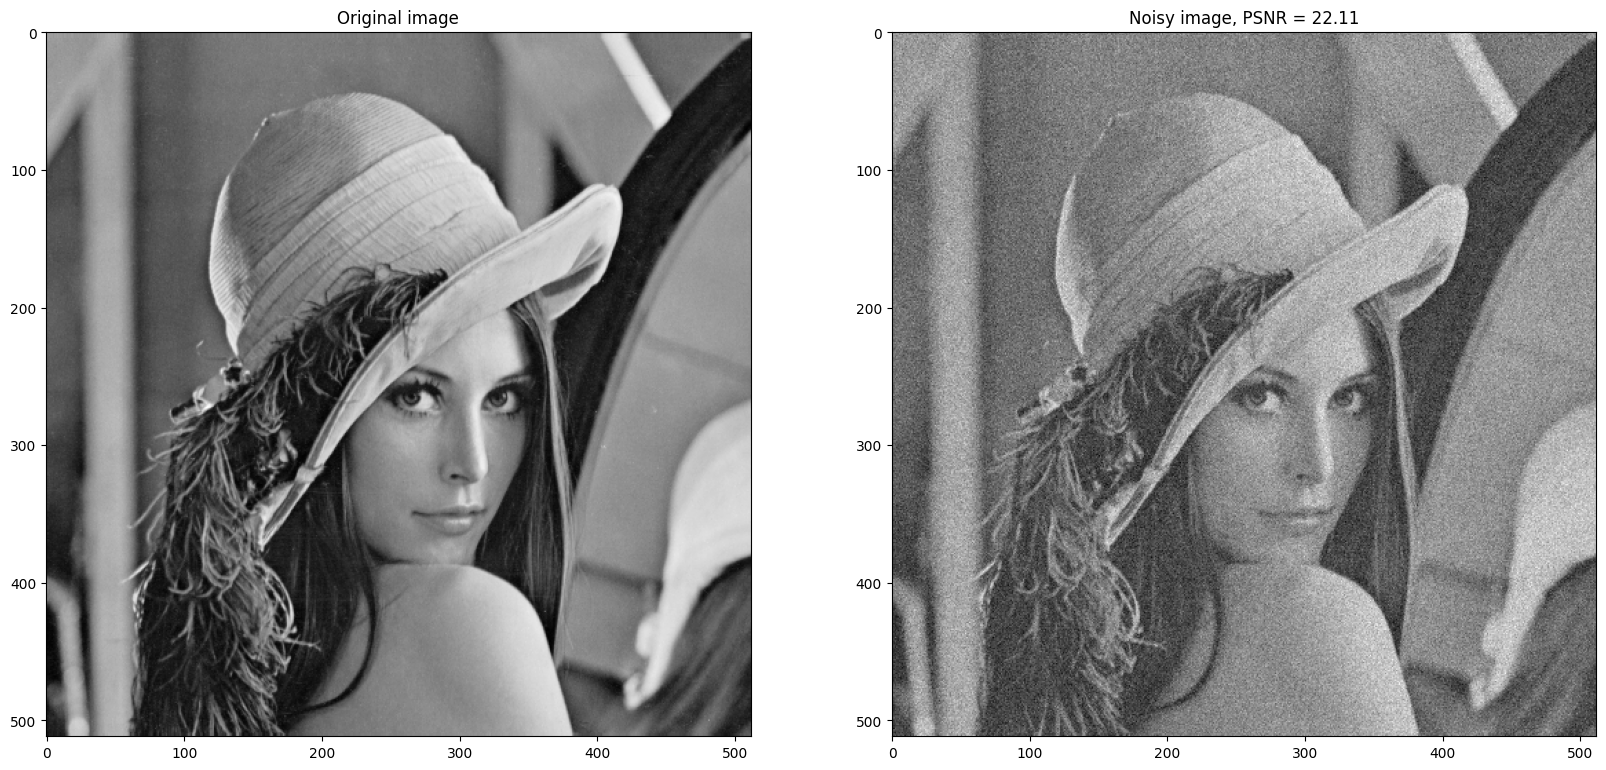

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Load and display the dictionary learned from patches

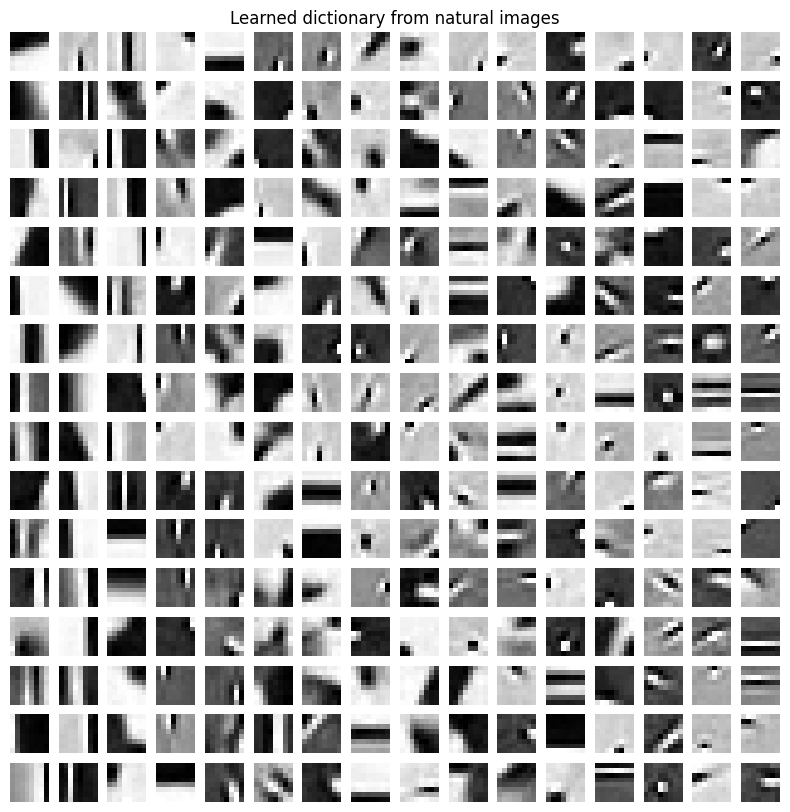

In [50]:
D = loadmat(f'{ROOT_FOLDER}/dict_nat_img.mat')['D']

# Display the learned basis
D_img = get_dictionary_img(D)
plt.figure(figsize=(10, 10))
plt.title('Learned dictionary from natural images')
plt.axis('off')
plt.imshow(D_img, cmap='gray')

Denoising via Sparse Coding
---------


In [51]:
# Initialize the estimated image
img_hat = np.zeros_like(img)

# Initialize the weight matrix
weights = np.zeros_like(img)

# Set the threshold
tau = 1.15 * p * sigma_noise

# Define the step
# STEP = p for non overlapping paches
STEP = 4

In [ ]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch with the top left corner at pixel (i, j)
        s = noisy_img[i:i + p, j:j + p].flatten()

        # Store and subtract the mean
        patch_mean = np.average(s)
        s -= patch_mean

        # Perform the sparse coding
        x = OMP(s, D, len(s) - 1, tau)         # OMP algorithm

        # Perform the reconstruction
        s_hat = D @ x

        # Add back the mean
        s_hat += patch_mean

        # Put the denoised patch into the estimated image using uniform weights
        w = 1                                 # uniform weights
        img_hat[i:i + p, j:j + p] += w * s_hat.reshape(p, p)

        # Store the weights of the current patch in the weight matrix
        weights[i:i + p, j:j + p] += w

Normalize the estimated image with the computed weights

In [53]:
img_hat = img_hat / weights

Compute the PSNR of the estimated image

Text(0.5, 1.0, 'Estimated Image,\nPSNR = 31.05')

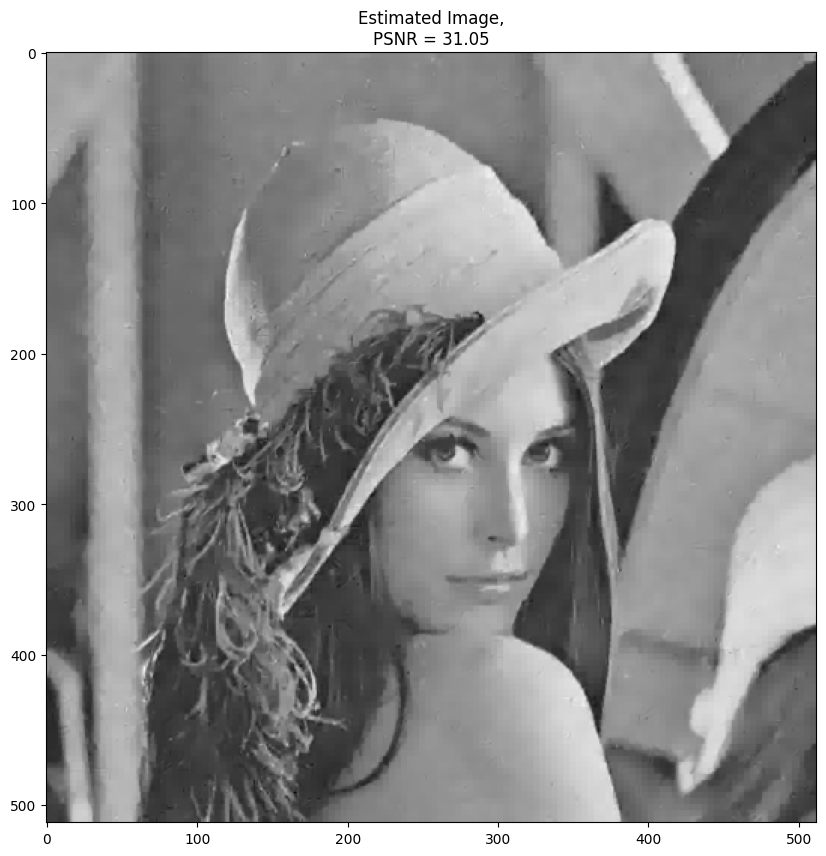

In [54]:
psnr_hat = 10 * np.log10(1/np.mean(np.square(img_hat - img)))
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')

Tikhonov Regularization Denoising
---------
Apply Tikhonov regularization and compare to OMP Denosing

In [55]:
# Initialize the estimated image
img_hat_tic = np.zeros_like(img)

# Initialize the weight matrix
weights_tic = np.zeros_like(img)

# Set the regularization parameter
lmbda = 1

# Precompute the Tikhonov matrix
_, N = D.shape
H_tic = np.linalg.inv((D.T @ D + lmbda * np.eye(N, N)))

In [56]:
for i in range(0, imsz[0] - p + 1, STEP):
    for j in range(0, imsz[1] - p + 1, STEP):
        # Extrach the patch with the top left corner at pixel (i, j)
        s = noisy_img[i:i + p, j:j + p].flatten()

        # Store and subtract the mean
        patch_mean = np.average(s)
        s -= patch_mean

        # Solve using Tikhonov closed form
        x_tic = H_tic @ D.T @ s

        # Perform the reconstruction
        s_hat = D @ x_tic

        # Add back the mean
        s_hat += patch_mean

        # Put the denoised patch into the estimated image using uniform weights
        w = 1                                 # uniform weights
        img_hat_tic[i:i + p, j:j + p] += w * s_hat.reshape(p, p)

        # Store the weights of the current patch in the weight matrix
        weights_tic[i:i + p, j:j + p] += w

Normalize the estimated image and evaluate the PSNR

Text(0.5, 1.0, 'Estimated Image (Tikhonov),\nPSNR = 25.81')

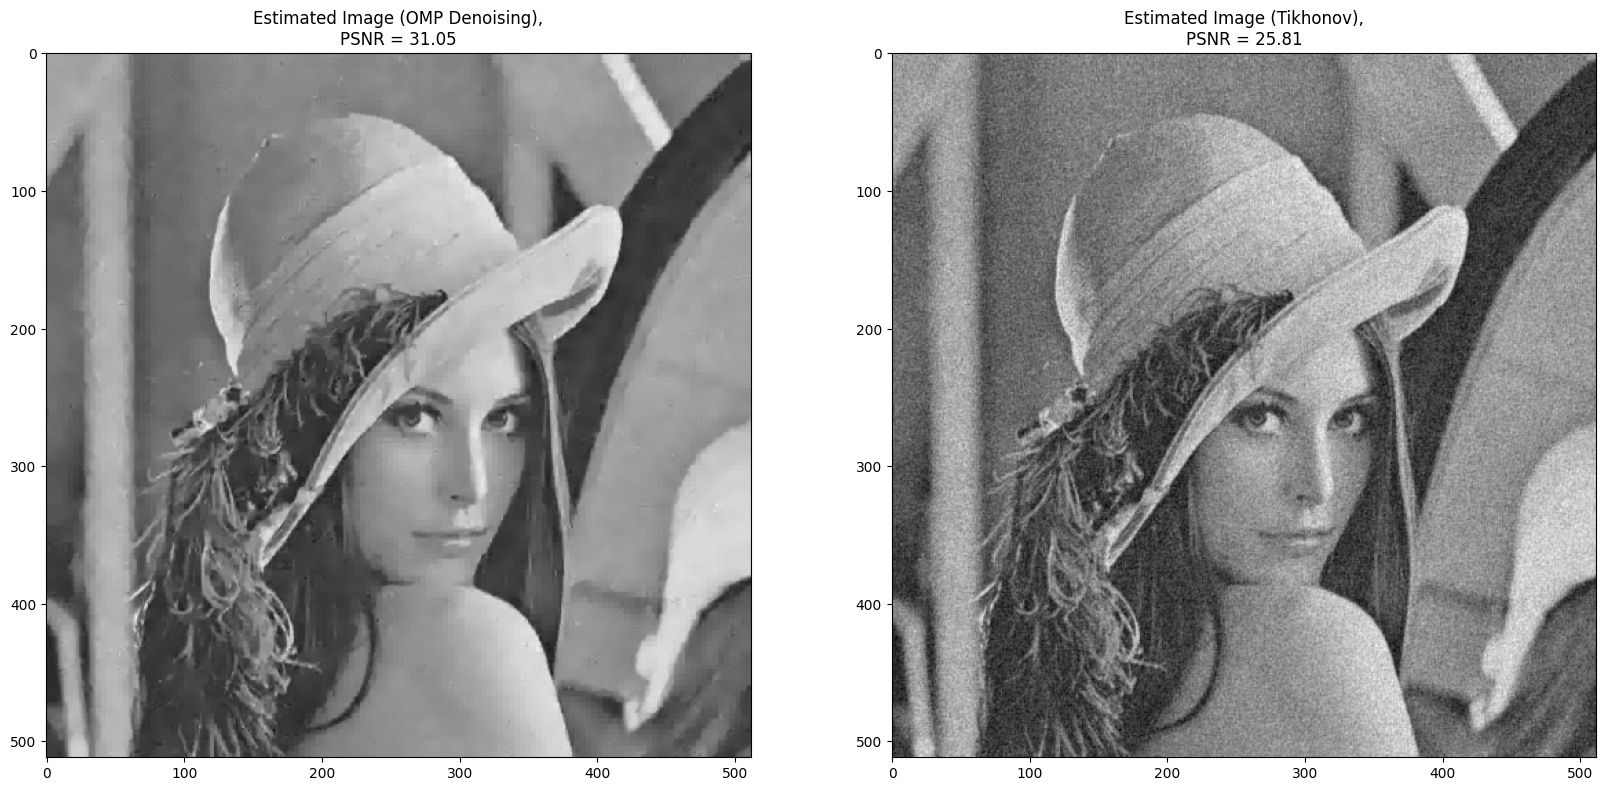

In [57]:
# Normalize the estimated image with the computed weights
img_hat_tic = img_hat_tic / weights_tic

# Compute the PSNR of the Tikhonov estimated image
psnr_hat_tic = 10 * np.log10(1/np.mean(np.square(img_hat_tic - img)))

fig, ax = plt.subplots(1, 2, figsize=(20, 10))

ax[0].imshow(img_hat, cmap='gray')
ax[0].set_title(f'Estimated Image (OMP Denoising),\nPSNR = {psnr_hat:.2f}')

ax[1].imshow(img_hat_tic, cmap='gray')
ax[1].set_title(f'Estimated Image (Tikhonov),\nPSNR = {psnr_hat_tic:.2f}')